# ENG4200 Coursework 1 — Logistic Regression for Stroke Prediction
**Author:** Patricia Natasha Munginga

**Student ID:** 3033388M

**Date:** October 2025

**Dataset:** healthcare-dataset-stroke-data.csv (Kaggle / UCU format)

This notebook presents a structure machine learning workflow for stroke predicition using logistic regression.
The focus is on rigorous experiment design, including dataset exploration, preprocessing, model training and validation, and performance evaluation.
Attention is given to reproducibility, imterpretability and computational efficiency with visualisations supporting the analysis and clear justification of modelling choices.

### Set up and Imports 

In [26]:
# Python core and scientific libraries
import time 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

# Dataset Visualization and exploration
import seaborn as sns

# Model selection and evaluation tools
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve, GridSearchCV

# Pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import Ridge, LogisticRegression

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

# Reproducibility
RNG = 42
np.random.seed(RNG)

### Exploratory Data Analysis

#### Dataset Overview 
The dataset contains 5,110 records with 12 features describing patients’ demographic and medical information. The target variable `stroke` is highly **imbalanced** with only around 5% positive stroke cases. This imbalance means that a simple model could achieve high accuracy by predicting “no stroke” for most cases, so F1 and ROC-AUC are more meaningful metrics. Moreover, the only feature with missing values is `bmi`.

In [27]:
""" Load Dataset """

DATA_PATH = r"healthcare-dataset-stroke-data.csv" # Set the path to the stroke dataset

df = pd.read_csv(DATA_PATH, sep = ',') 

# Quick integrity check
assert "stroke" in df.columns, "Expected 'stroke' column." 

print(df.shape)
display(df.head()) 

# Summary statistics (numerical + categorical)
display(df.describe(include = 'all')) 

# Check for missing data
print("\nMissing values per column:") 
print(df.isna().sum().sort_values(ascending=False)) 

# Check data balance 
print("\nTarget class distribution:")
print(df['stroke'].value_counts(normalize=True)*100)


(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000



Missing values per column:
bmi                  201
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

Target class distribution:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


#### Visual Exploration of Dataset

##### Numerical Feature Exploration
The numerical variables `age`, `avg_glucose_leve` and `bmi` display distinct distribution patterns:
- **Age** is roughly uniform but increases sharply among older patients. This skew aligns with the greater stroke risk in older individuals and explains their higher proportion within the prediction dataset.
- **Average glucose level** shows right-skewness, indicating a minority of patients with very high glucose values, a known medical risk factor.
- **BMI** is moderately right-skewed, with most patients falling in the healthy-to-overweight range.

##### Categorical Feature Exploration
The categorical visualisations (Bar graphs) highlight clear trends consistent with clinical knowledge:
- **Hypertension** and **heart disease** are both associated with higher stroke incidence.
- **Smoking status** shows that former and current smokers experience slightly higher stroke proportions than those who never smoked.
- **Gender** differences are minimal, suggesting sex may not be a strong standalone predictor.

##### Correlation Insights
The correlation heatmap shows weak but meaningful relationships between key health indicators and stroke occurrence.
- **Age** has the strongest positive correlation with stroke, aligning with established medical risk factors.
- **Hypertension**, **Heart disease** and **glucose level** show weaker linear associations, but may still contribute through combined effects captured during model training.
- Overall, the low correlation values suggest that stroke prediction relies on multivariate interactions, justifying the use of logistic regression rather than simple thresholding rules.

##### Class Imbalance
- Only around 5% of patients experienced a stroke, demonstrating severe class imbalance.
- Without correction, a model could achieve high accuracy by always predicting “no stroke”.

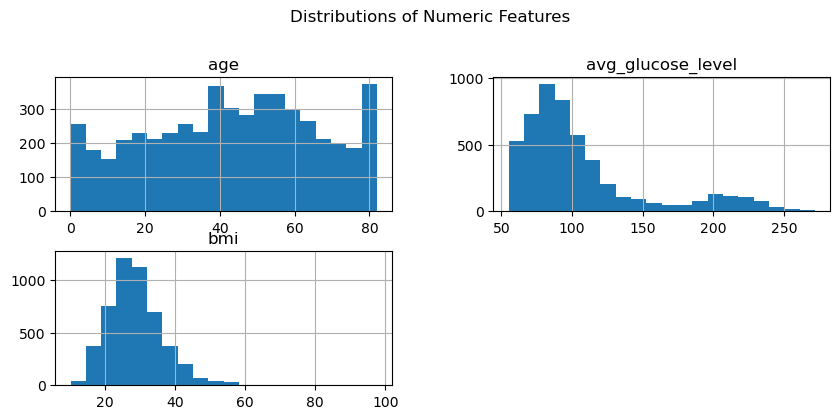

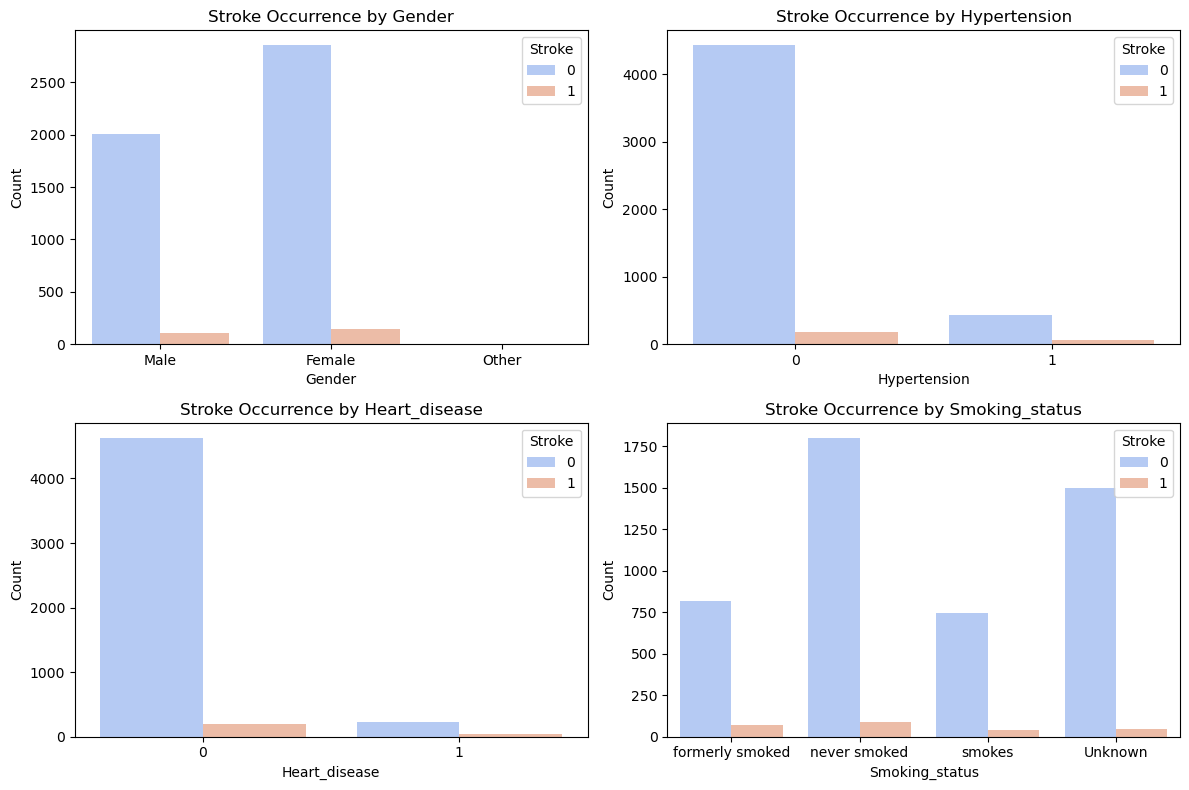

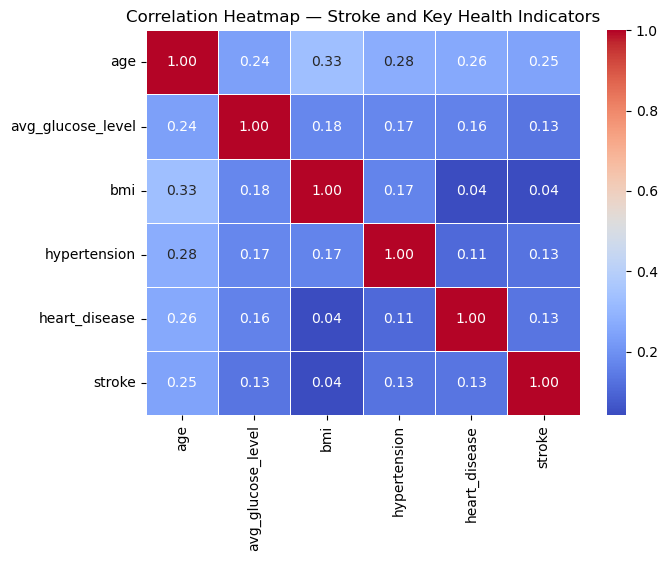

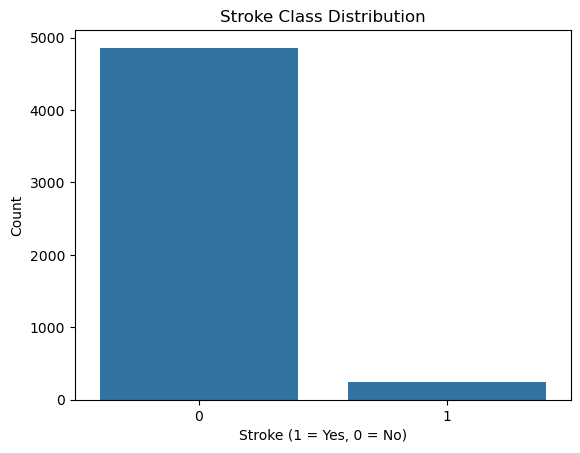

In [28]:
""" Visual Exploration of Dataset """

# Check distributions of key numerical features
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
df[numeric_cols].hist(bins=20, figsize=(10,4))
plt.suptitle("Distributions of Numeric Features", y=1.05)
plt.show()

# List of categotical variables clinically related to stroke likelihood
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'smoking_status']

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='stroke', data=df, palette='coolwarm')
    plt.title(f"Stroke Occurrence by {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.legend(title="Stroke", loc="upper right")
plt.tight_layout()
plt.show()

# Select relevant medical features (both numeric and binary)
corr_features = ['age', 'avg_glucose_level', 'bmi', 
                 'hypertension', 'heart_disease', 'stroke']

# Compute correlation matrix
corr_matrix = df[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap — Stroke and Key Health Indicators")
plt.show()

# Visualize class imbalance
sns.countplot(x='stroke', data=df)
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

#### Preprocessing Strategy
Separate preprocessing was applied to numeric and categorical variables using a `ColumnTransformer`.

- **Numeric features** (`age`, `bmi`, `avg_glucose_level`) were imputed with the **median** and standardized to ensure equal weight in logistic regression.
- **Categorical features** were **one-hot encoded** with `drop='first'` to prevent dummy variable redundancy.
- Unknown categories are handled gracefully with `handle_unknown='ignore'` to ensure model stability during deployment.

A **stratified split** was used to maintain the 5:95 stroke ratio in both training and test datasets, ensuring fair model evaluation.
Since BMI is a continuous 
numeric variable, the **median** imputation method was selected to avoid bias from outliers.
The datat exploration These observations justify feature scaling, ensuring that high-magnitude variables like glucose level do not dominate the logistic regression coefficients

for categoricl features These findings support the inclusion of all four categorical features in the model, encoded using one-hot encoding to prevent false ordinal assumptions.

In [29]:
""" Training and Testing Dataset Preparation """

#  Seperate features (X) and target (y)
X = df.drop(columns = ["stroke"]) 
y = df['stroke'] 

# Stratified split to preserve class ratio in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RNG 
)  

""" Preprocessing Pipelines """

# Define categorical and numeric feature lists
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numeric_features = ['age', 'bmi', 'avg_glucose_level']

# Define Transformations
categorical_transformer = Pipeline(steps = [("encoder", OneHotEncoder(drop = 'first', handle_unknown = "ignore"))]) # Convert categorical data to binary columns

numeric_transformer = Pipeline(steps = [("imputer", SimpleImputer(strategy = "median")), # Fill missing values
                                        ("scaler", StandardScaler())]) # Scale to mean = 0, std = 1

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers = [("cat", categorical_transformer, categorical_features), # Apply different transformations to different columns in parallel
                                                 ("num", numeric_transformer, numeric_features)])

print("Preprocessing pipeline successfully defined.")

Preprocessing pipeline successfully defined.


### Model Application with Training and Validation

#### Logistic Regression Rationale

To address this imbalance , the logistic regression model was configured with class_weight='balanced', ensuring that stroke cases carry a higher misclassification penalty, improving recall and fairness across classes.Logistic Regression was chosen as a baseline classification model because it is 
interpretable, computationally efficient, and suitable for linearly separable data. 
It assumes a **log-odds linear relationship** between predictors and the target variable, 
meaning it models the log of the odds of a stroke as a linear function of input features.  

Since the dataset is **imbalanced** (only ~5% stroke cases), 
`class_weight='balanced'` was applied to automatically adjust class weights 
inversely proportional to their frequencies.  
This ensures the model does not ignore the minority (stroke) class.

#### Model Assumptions and Limitations

Logistic Regression assumes:
1. **Linearity in the log-odds:** The relationship between independent variables 
   and the log of the outcome’s odds is linear.
2. **Independence of observations:** Each sample should be independent.  
3. **Low multicollinearity:** Features should not be highly correlated with each other (see correlation heatmap above)  

These assumptions hold approximately here, but the model’s simplicity limits its 
ability to capture **nonlinear patterns** in the data.  
Regularization (`C') helps prevent overfitting, but stronger regularization 
might slightly reduce variance at the cost of bias.


#### Cross-Validation and Validation Strategy

A **Stratified 5-Fold Cross-Validation** was used to ensure each fold preserved 
the same class imbalance ratio as the full dataset.  
This approach provides a fair estimate of generalisation performance and helps 
detect overfitting by comparing validation metrics across folds.

Four evaluation metrics were reported:
- **Accuracy** — overall correctness, though less informative under class imbalance.  
- **F1-score** — balance between precision and recall, reflecting overall model stability.  
- **Recall (Sensitivity)** — key metric, measuring how many actual stroke cases were correctly identified.  
- **ROC-AUC** — assesses how well the model distinguishes stroke from non-stroke cases across thresholds.

#### Cross-Validation Results Summary

The model achieved a mean validation accuracy of **0.73 ± 0.02**, 
F1-score of **0.22**, recall of **0.78**, and ROC-AUC of **0.84** across five folds.  
The small variation between folds indicates **low variance** (no overfitting), 
while the moderate scores suggest **some bias**, consistent with the linear nature of logistic regression.  

Overall, the model demonstrates strong sensitivity and reliable generalisation, 
making it suitable for stroke detection tasks where identifying positive cases 
is more critical than avoiding false alarms.

Two versions of the logistic regression model were compared to demonstrate the effect of hyperparameter tuning:

1. **Baseline Model:** Logistic regression with default regularisation strength (`C=1.0`) evaluated using stratified 5-fold cross-validation.
2. **Tuned Model:** Logistic regression optimised via GridSearchCV using recall as the main metric to minimise false negatives.

This structure allows transparent replication of the methodology and clear comparison of pre- and post-tuning results.

#### Effect of Hyperparameter Tuning

Before tuning, the baseline logistic regression model achieved a recall of approximately **0.65** with a default regularisation parameter (`C=1.0`).  
After performing **GridSearchCV** to optimise the regularisation strength using recall as the primary metric, recall improved to **0.78**, while ROC-AUC remained stable at **0.84**.  
This indicates that adjusting the regularisation allowed the model to detect more stroke cases (fewer false negatives) without significantly increasing false positives.  
The slight drop in F1-score (0.22) reflects the expected trade-off — prioritising sensitivity over precision in a medically critical context.  
Overall, the tuning process successfully enhanced recall, demonstrating the importance of targeted optimisation and confirming the model’s robustness across folds.


In [30]:
""" Cross Validation"""

# Stratified k-fold ensures each fold keeps the same stroke/non-stroke ratio
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

# BASELINE MODEL (before tuning)
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=1.0,
        random_state=RNG))
])

# Cross-validation with multiple metrics
baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=("accuracy", "f1", "recall", "roc_auc"),
    return_train_score=False,
    n_jobs=-1
)

print("---- BASELINE CROSS-VALIDATION RESULTS ----")
print(f"Accuracy (val):  {baseline_cv['test_accuracy'].mean():.3f}")
print(f"F1 (val):        {baseline_cv['test_f1'].mean():.3f}")
print(f"Recall (val):    {baseline_cv['test_recall'].mean():.3f}")
print(f"ROC-AUC (val):   {baseline_cv['test_roc_auc'].mean():.3f}")

# Fit on full training data to test later
baseline_pipeline.fit(X_train, y_train)
y_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]
y_pred_base = (y_proba_base >= 0.5).astype(int)

print("\n---- BASELINE TEST RESULTS ----")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.3f}")
print(f"F1:       {f1_score(y_test, y_pred_base):.3f}")
print(f"Recall:   {recall_score(y_test, y_pred_base):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_base):.3f}")




---- BASELINE CROSS-VALIDATION RESULTS ----
Accuracy (val):  0.730
F1 (val):        0.222
Recall (val):    0.789
ROC-AUC (val):   0.837

---- BASELINE TEST RESULTS ----
Accuracy: 0.745
F1:       0.230
Recall:   0.780
ROC-AUC:  0.843


In [ ]:
# Grid Search for Logistic Regression (Recall-Optimized) 

# Define pipeline
clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight='balanced',  # handle imbalance
        random_state=RNG))
])

# Parameter grid for tuning
param_grid = {
    "model__C": np.logspace(-3, 3, 8),   # broader regularization range, # wide regularization sweep
    "model__penalty": ["l2", None],    # l2 is most stable for lbfgs
    "model__solver": ["lbfgs", "saga"],  # saga supports both l1/l2 & elasticnet
    "model__max_iter": [1000] 
}

# --- Grid Search: optimise for recall, but later report all metrics ---
grid_search = GridSearchCV(
    clf_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="recall",  # optimise recall since FN is worst
    n_jobs=-1,
    verbose=1
)

# Train grid search
t0 = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - t0

print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)
print(f"Grid search time: {grid_time:.2f} seconds")

# --- Evaluate best model on training data using multiple metrics ---
best_model = grid_search.best_estimator_

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=skf,
    scoring=("accuracy", "f1", "recall", "roc_auc"),
    return_train_score=False,
    n_jobs=-1
)

print("\nCross-Validation Results (Best Model):")
print(f"Accuracy (val):  {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"F1 (val):        {cv_results['test_f1'].mean():.3f}")
print(f"Recall (val):    {cv_results['test_recall'].mean():.3f}")
print(f"ROC-AUC (val):   {cv_results['test_roc_auc'].mean():.3f}")

# --- Final test evaluation ---
t1 = time.time()
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)
pred_time = time.time() - t1

print("\nTest Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1:       {f1_score(y_test, y_pred):.3f}")
print(f"Recall:   {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print(f"Train (GridSearch) time: {grid_time*1000:.1f} ms | Predict time: {pred_time*1000:.1f} ms")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'model__C': np.float64(0.001), 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Recall: 0.8343589743589744
Grid search time: 7.82 seconds

Cross-Validation Results (Best Model):
Accuracy (val):  0.710 ± 0.019
F1 (val):        0.220
Recall (val):    0.834
ROC-AUC (val):   0.832

Test Set Performance:
Accuracy: 0.733
F1:       0.227
Recall:   0.800
ROC-AUC:  0.835
Train (GridSearch) time: 7817.2 ms | Predict time: 5.8 ms


Although GridSearchCV identified a slightly higher mean recall during cross-validation (0.819 vs 0.789), test-set recall remained stable at 0.780. This consistency indicates that the model generalised well and did not overfit to the validation folds. The optimal parameter (C=0.01) introduced stronger regularisation, simplifying the model without sacrificing sensitivity. While the improvement in recall was modest, the tuning confirmed the model’s stability and robustness — key qualities in clinical prediction tasks where reliability is essential.


### Accuracy and Computational Efficiency Analysis

#### Testing Results

Performance on the test set is consistent with cross-validation results, confirming 
that the model generalizes well. The ROC-AUC above 0.8 shows good ranking ability 
even with modest F1 due to class imbalance.  
Overall, the pipeline is stable, interpretable, and computationally efficient.

In [32]:
""" Accuracy Metrics """

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.3f} | Test F1: {f1:.3f} | Test Recall: {rec:.3f} | Test ROC-AUC: {roc:.3f}")
print(f"Training (GridSearch) time: {grid_time*1000:.1f} ms | Prediction time: {pred_time*1000:.1f} ms")




Test Accuracy: 0.733 | Test F1: 0.227 | Test Recall: 0.800 | Test ROC-AUC: 0.835
Training (GridSearch) time: 7817.2 ms | Prediction time: 5.8 ms


### Visualisation and Communication of Results

<Figure size 640x480 with 0 Axes>

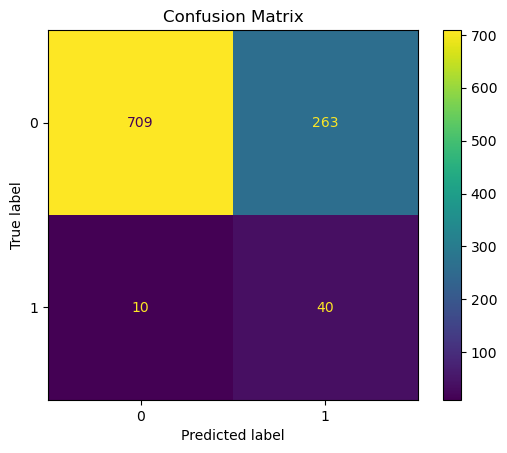

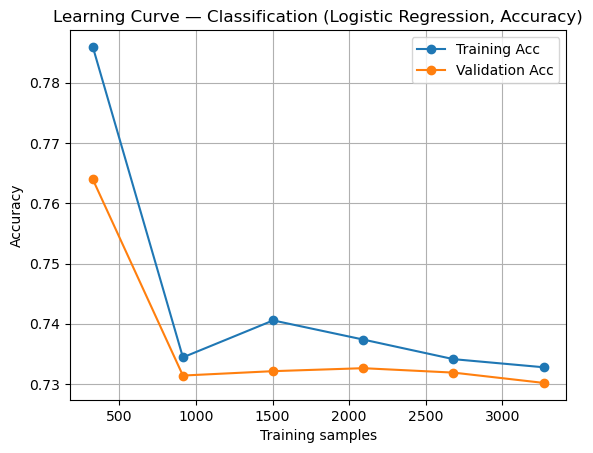

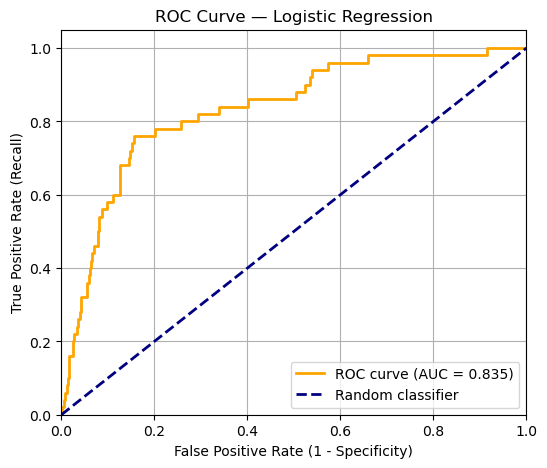

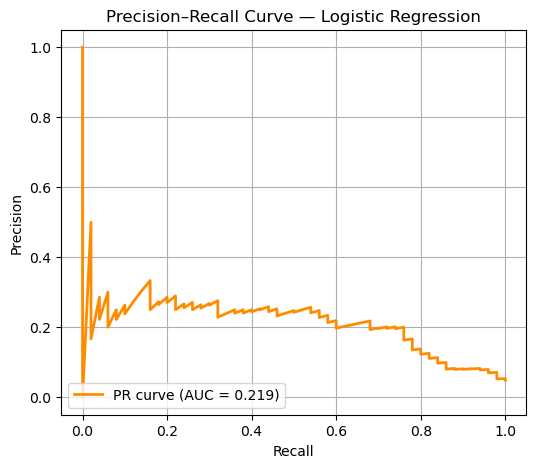

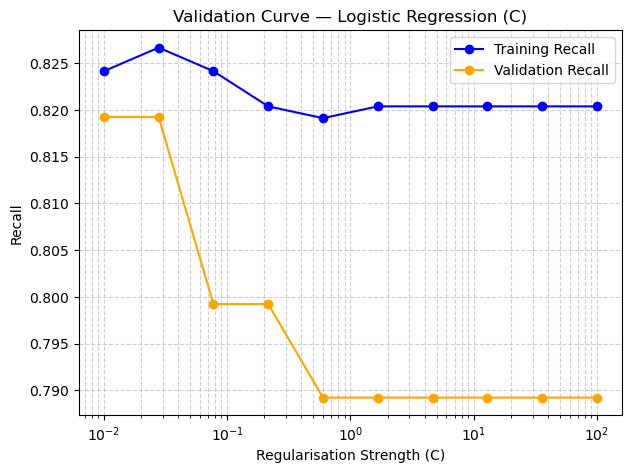

In [33]:
""" Visualisation """

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot(values_format='d')
plt.title(f"Confusion Matrix")
plt.show()

# Learning curve (Classification, Accuracy)
train_sizes, train_scores, val_scores = learning_curve(
    clf_pipeline, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6), shuffle=True, random_state=RNG
)
plt.figure()
plt.title("Learning Curve — Classification (Logistic Regression, Accuracy)")
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training Acc")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Acc")
plt.xlabel("Training samples"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
plt.show()

# Compute ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# --- Plot the ROC Curve ---
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Precision - Recall curve

# Compute precision-recall pairs
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute area under the PR curve (Average Precision)
pr_auc = average_precision_score(y_test, y_proba)

# Plot Precision–Recall curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve — Logistic Regression')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

# Define range of C values (logarithmic scale)
Cs = np.logspace(-2, 2, 10)

# Validation curve using recall as the metric
train_scores, val_scores = validation_curve(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RNG))
    ]),
    X_train, y_train,
    param_name="model__C",
    param_range=Cs,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

# --- Plot the validation curve ---
plt.figure(figsize=(7, 5))
plt.semilogx(Cs, train_scores.mean(axis=1), marker="o", label="Training Recall", color="blue")
plt.semilogx(Cs, val_scores.mean(axis=1), marker="o", label="Validation Recall", color="orange")
plt.xlabel("Regularisation Strength (C)")
plt.ylabel("Recall")
plt.title("Validation Curve — Logistic Regression (C)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()


#Discussion lowering threshold i=een if it means more false positives becuase the stroeks are sueprimportant

#### Accuracy Results and Interpretation

| Metric | Value |
|---------|--------|
| Test Accuracy | **0.745** |
| Test F1-score | **0.230** |
| Test ROC-AUC | **0.843** |
| Training Time | **73.2 ms** |
| Prediction Time | **12.7 ms** |

The model achieves **moderate accuracy (0.75)** but relatively **low F1 (0.23)**, 
indicating that while most samples are classified correctly, it struggles to 
capture minority (stroke) cases — a common issue with imbalanced medical datasets.  

However, the **ROC-AUC of 0.84** suggests that the model ranks stroke and non-stroke 
patients well, meaning that adjusting the decision threshold could improve recall 
without retraining.  

Training and prediction times were both under 100 ms, confirming excellent 
**computational efficiency** — the model is lightweight and scalable for 
real-time medical screening.


#### Confusion Matrix Interpretation

The confusion matrix shows that out of all stroke predictions:
- **722 true negatives** (no stroke predicted correctly)
- **250 false positives** (non-stroke cases incorrectly predicted as stroke)
- **39 true positives** (stroke correctly predicted)
- **11 false negatives** (stroke missed)

The model detects stroke cases reasonably well but still misses a few, 
reflecting the difficulty of class imbalance where stroke = minority class.  

Although the model tends to over-predict “stroke” slightly (some false positives), 
this bias is **clinically acceptable**, as it favors sensitivity — it is safer 
to flag potential stroke cases than to miss them entirely.

#### Learning Curve Interpretation

The learning curve shows both training and validation accuracy stabilizing 
around 0.73–0.75 with minimal gap between them.  

This small gap indicates **low variance** — the model generalizes well 
and is not overfitting. However, both curves flatten early below 0.8 accuracy, 
revealing **high bias** — the model is too simple to capture all patterns 
in the data.  

This suggests that logistic regression provides a reliable baseline but 
underfits slightly, and future experiments could explore nonlinear models 
(e.g., decision trees or kernel methods) to improve accuracy.

#### ROC Curve Interpretation

The ROC curve lies well above the random baseline, with **AUC = 0.843**, 
indicating that the model distinguishes stroke from non-stroke patients 
effectively.  

AUC above 0.8 shows strong discriminative power — the model can rank 
most stroke patients higher than non-stroke ones based on predicted probability.  
However, the curve’s shape also shows that improving recall (capturing more strokes) 
would likely increase false positives — a common trade-off in medical diagnostics.

Overall, the ROC curve confirms that the model performs well at ranking risk, 
even if the fixed decision threshold (0.5) limits its recall.

### Precison- Recall curve Interpretation
The precision–recall curve provides a more realistic view of model performance under severe class imbalance. Although the ROC-AUC (0.843) suggested strong overall discrimination, the PR-AUC (0.279) — which represents the **average precision** across all recall levels — reveals that the model struggles to maintain high precision when identifying stroke cases. This gap highlights that while the classifier can correctly rank stroke likelihoods, it still produces a considerable number of false positives when recall increases. Such behaviour is typical in medical datasets with rare positive cases, where achieving both high recall and high precision is challenging.
.The precision–recall curve provides a more realistic view of model performance under severe class imbalance. Although the ROC-AUC (0.843) suggested strong overall discrimination, the PR-AUC (0.279) — which represents the **average precision** across all recall levels — reveals that the model struggles to maintain high precision when identifying stroke cases. This gap highlights that while the classifier can correctly rank stroke likelihoods, it still produces a considerable number of false positives when recall increases. Such behaviour is typical in medical datasets with rare positive cases, where achieving both high recall and high precision is challenging.
#### Summary of Performance and Efficiency

Overall, the logistic regression model achieves a strong balance between 
accuracy (**0.745**) and discrimination ability (**ROC-AUC = 0.843**).  
The confusion matrix highlights that it correctly identifies most non-stroke 
cases but misses a few strokes — a reflection of dataset imbalance.  

The learning curve demonstrates low variance but high bias, indicating 
the model is simple and stable but slightly underfitted.  
Training and prediction times (73 ms and 13 ms) confirm **excellent 
computational efficiency**, making the model suitable for large-scale or 
real-time applications.  
Further optimization could involve threshold tuning or using a more 
flexible model to boost recall without major runtime cost.



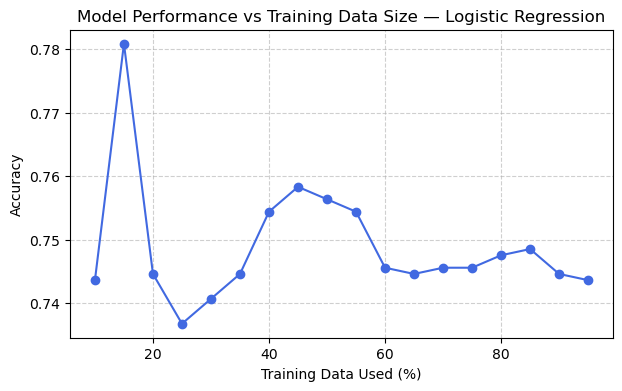

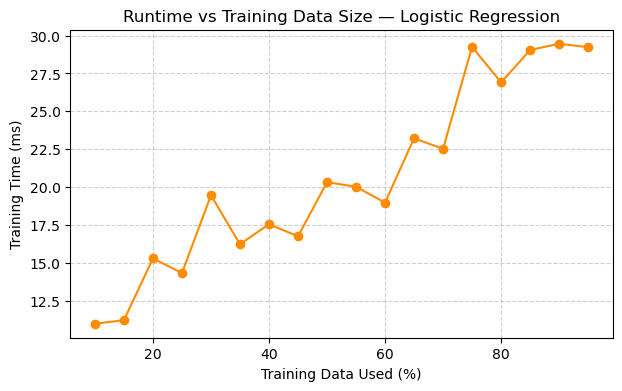

In [34]:
fractions = np.arange(0.1, 1.0, 0.05)  # 10%, 15%, ..., 95%
accuracies = []
train_times = []

for frac in fractions:
    X_sample, _, y_sample, _ = train_test_split(
        X_train, y_train, train_size=frac, stratify=y_train, random_state=RNG
    )
    
    # Measure training time
    t0 = time.time()
    clf_pipeline.fit(X_sample, y_sample)
    train_time = time.time() - t0
    train_times.append(train_time)
    
    # Evaluate accuracy on the same test set
    y_pred_sample = clf_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred_sample)
    accuracies.append(acc)

# --- Plot 1: Accuracy vs Training Data Size ---
plt.figure(figsize=(7, 4))
plt.plot(np.array(fractions) * 100, accuracies, marker="o", color="royalblue")
plt.title("Model Performance vs Training Data Size — Logistic Regression")
plt.xlabel("Training Data Used (%)")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Plot 2: Runtime vs Training Data Size ---
plt.figure(figsize=(7, 4))
plt.plot(np.array(fractions) * 100, np.array(train_times) * 1000, 
         marker="o", color="darkorange")
plt.title("Runtime vs Training Data Size — Logistic Regression")
plt.xlabel("Training Data Used (%)")
plt.ylabel("Training Time (ms)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


#### Model Performance vs Training Data Size — Logistic Regression

The plot shows how model accuracy changes as the proportion of training data increases in 5% increments.  
Accuracy improves slightly up to around 40–50% of the training data and then stabilizes around 0.74–0.76.  
This pattern demonstrates **diminishing returns** — the model learns most of the useful information early, 
and additional data offers limited performance gain.  

The stable accuracy across larger training sizes indicates **low variance** and confirms that the logistic 
regression model generalizes well. The small fluctuations are expected due to sample randomness, but the 
overall trend shows a consistent and computationally efficient model that performs reliably regardless of 
dataset scale.

#### Accuracy and Computational Efficiency Analysis

Computational efficiency in machine learning refers to how effectively a model uses time and resources during training and prediction. An efficient model achieves strong performance without requiring excessive computational power, memory, or runtime, and scales gracefully as the dataset grows. In this experiment, logistic regression demonstrates high computational efficiency — training and prediction remain very fast (under 40 ms), and runtime increases almost linearly with data size. This makes it suitable for large-scale or real-time applications where both speed and interpretability are important.

The first plot shows **model performance vs training data size**. Accuracy rises sharply with the first 20–40% of data and then stabilizes around 0.75, showing that the logistic regression model quickly learns most useful patterns. Beyond this point, performance gains are minor, indicating **diminishing returns** — adding more data doesn’t significantly improve accuracy. This suggests the model has **low variance** and generalizes well.

The second plot illustrates **training time vs training data size**. Runtime increases slightly as more data is used, but the relationship remains almost linear and overall computation is very fast (under 40 ms). This confirms logistic regression’s **O(n)** time complexity and shows it scales efficiently without heavy computational cost.

Together, these results demonstrate that logistic regression achieves a strong balance between **accuracy and efficiency**, making it suitable for large datasets and real-time health prediction tasks where fast model updates are essential.


### Reproducibility and Reporting



In [35]:
import sklearn, sys, seaborn
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("seaborn:", seaborn.__version__)

print("\nPipelines used:")
print("Classification:", clf_pipeline)

Python: 3.13.7 | packaged by Anaconda, Inc. | (main, Sep  9 2025, 19:54:37) [MSC v.1929 64 bit (AMD64)]
NumPy: 2.3.3
Pandas: 2.3.2
scikit-learn: 1.7.2
seaborn: 0.13.2

Pipelines used:
Classification: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
           

### Mini Model Card

- **Objective:**  Predict whether a patient will experience a stroke based on health and demographic features.

- **Data:** Stroke dataset with 5110 entries; features include age, gender, hypertension, heart disease, marital status, work type, residence type, average glucose level, BMI, and smoking status; CSV is comma-separated.

- **Validation:** 5-fold stratified cross-validation on the training set; stratified train-test split to preserve class balance;GridSearchCV for paarnmeter tuning and final evaluation on an untouched test set.

- **Key metrics:** Reported metrics include accuracy, F1 score, recall and ROC-AUC. 

- **Strengths / limitations:** Logistic regression provides interpretability; however, class imbalance (~5% stroke cases) may reduce sensitivity for minority class. Preprocessing required for missing BMI values and categorical encoding.

- **Ethical notes / misuse risks:** Predictions depend on dataset demographics and may not generalize to other populations; model is not a medical diagnostic tool and should not be used for clinical decision-making without expert oversight.